### Detection psychometric function
Edit the numbers marked `👈` and re-run.

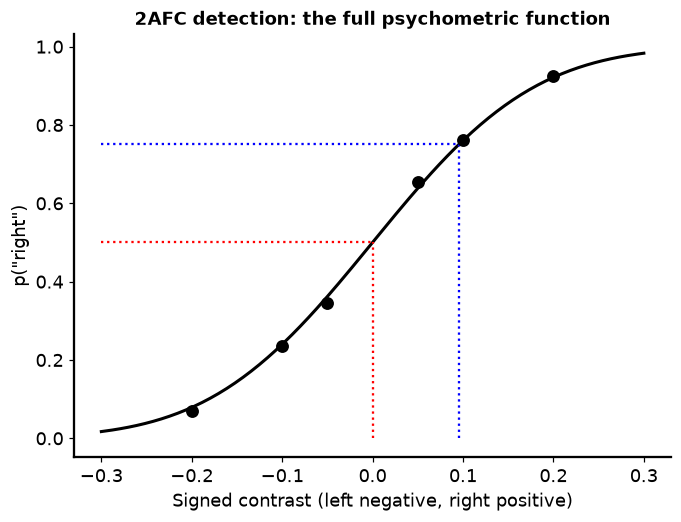

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 12, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})

# A 2AFC detection task: signal appears left or right, observer picks the stronger side
signal_strengths = np.array([0.05, 0.1, 0.2])   # 👈 contrasts presented
noise_sd = 0.1                                    # 👈 internal noise
ntrials  = 1000

rng = np.random.default_rng()
half = ntrials // 2
left  = rng.standard_normal((ntrials, signal_strengths.size)) * noise_sd
right = rng.standard_normal((ntrials, signal_strengths.size)) * noise_sd
left[:half]  += signal_strengths     # first half: signal on the left
right[half:] += signal_strengths     # second half: signal on the right

responses_right = (right - left) > 0              # respond "right" if right felt stronger
p_right_when_left  = responses_right[:half].mean(axis=0)   # signal was on the left
p_right_when_right = responses_right[half:].mean(axis=0)   # signal was on the right

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(-signal_strengths, p_right_when_left, 55, color="k", zorder=3)
ax.scatter( signal_strengths, p_right_when_right, 55, color="k", zorder=3)

xs = np.linspace(-0.3, 0.3, 200)
ax.plot(xs, norm.cdf(xs, 0, noise_sd * np.sqrt(2)), color="k", lw=2)

# the point of subjective equality (0.5) and the 75%-correct threshold
threshold = norm.ppf(0.75, 0, noise_sd * np.sqrt(2))
ax.plot([-0.3, 0], [0.5, 0.5], "r:", lw=1.5); ax.plot([0, 0], [0, 0.5], "r:", lw=1.5)
ax.plot([-0.3, threshold], [0.75, 0.75], "b:", lw=1.5); ax.plot([threshold, threshold], [0, 0.75], "b:", lw=1.5)

ax.set(xlabel="Signed contrast (left negative, right positive)", ylabel='p("right")',
       title="2AFC detection: the full psychometric function")
plt.show()
